[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jdsanch1/simrc/blob/master/02.%20Parte%202/09.%20Clase%209/09Class%20NB.ipynb)

In [ ]:
!pip install -q yfinance pandas numpy matplotlib seaborn scipy scikit-learn statsmodels

# Clase 9:	Optimización de portafolios usando simulación Montecarlo

[Juan Diego Sánchez Torres](https://www.researchgate.net/profile/Juan_Diego_Sanchez_Torres), 

*Profesor*, [MAF ITESO](http://maf.iteso.mx/web/general/detalle?group_id=5858156)

+ Departamento de Matemáticas y Física
+ dsanchez@iteso.mx
+ Tel. 3669-34-34 Ext. 3069
+ Oficina: Cubículo 4, Edificio J, 2do piso

# 1. Motivación

En primer lugar, para poder bajar precios y información sobre opciones de Yahoo, es necesario cargar algunos paquetes de Python. En este caso, el paquete principal será Pandas. También, se usarán el Scipy y el Numpy para las matemáticas necesarias y, el Matplotlib y el Seaborn para hacer gráficos de las series de datos.

In [1]:
#importar los paquetes que se van a usar
import pandas as pd
import yfinance as yf
import numpy as np
import datetime
from datetime import datetime
import scipy.stats as stats
import scipy as sp
import scipy.optimize as scopt
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.covariance as skcov
%matplotlib inline
#algunas opciones para Python
pd.set_option('display.notebook_repr_html', True)
pd.set_option('display.max_columns', 6)
pd.set_option('display.max_rows', 10)
pd.set_option('display.width', 78)
pd.set_option('precision', 3)

# 2. Uso de Pandas para descargar datos de precios de cierre

Bajar datos en forma de función

In [2]:
def get_historical_closes(tickers, start_date, end_date):
    """Descarga precios de cierre ajustados usando yfinance."""
    import yfinance as yf
    import pandas as pd
    data = yf.download(tickers, start=start_date, end=end_date,
                       auto_adjust=True, progress=False)
    if isinstance(data.columns, pd.MultiIndex):
        closes = data["Close"]
    else:
        closes = data[["Close"]]
        closes.columns = [tickers] if isinstance(tickers, str) else list(tickers)
    closes.index.name = "Date"
    return closes.dropna()

Una vez cargados los paquetes, es necesario definir los tickers de las acciones que se usarán, la fuente de descarga (Yahoo en este caso, pero también se puede desde Google) y las fechas de interés. Con esto, la función *DataReader* del paquete *pandas_datareader* bajará los precios solicitados.

**Nota**: Usualmente, las distribuciones de Python no cuentan, por defecto, con el paquete *pandas_datareader*. Por lo que será necesario instalarlo aparte. El siguiente comando instala el paquete en Anaconda:
*conda install -c conda-forge pandas-datareader *

In [3]:
assets = ['AAPL','AMZN','MSFT','KO']
closes=get_historical_closes(assets, '2010-01-01', '2016-12-31')
closes

Ticker,AAPL,AMZN,KO,MSFT
Date,,,,
2010-01-04,27.505,133.90,22.554,25.275
2010-01-05,27.553,134.69,22.282,25.283
2010-01-06,27.114,132.25,22.274,25.128
2010-01-07,27.064,130.00,22.218,24.867
2010-01-08,27.244,133.52,21.807,25.038
...,...,...,...,...
2016-12-23,115.088,760.59,40.577,62.169
2016-12-27,115.819,771.40,40.586,62.209
2016-12-28,115.325,772.13,40.372,61.924


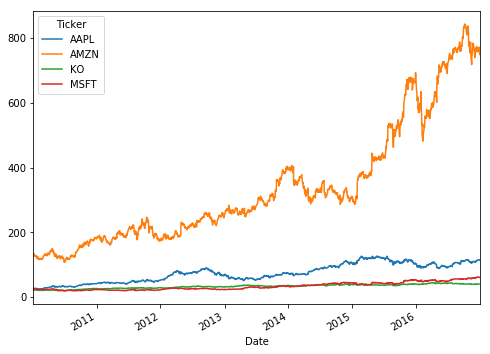

In [4]:
closes.plot(figsize=(8,6));

**Nota**: Para descargar datos de la bolsa mexicana de valores (BMV), el ticker debe tener la extensión MX. 
Por ejemplo: *MEXCHEM.MX*, *LABB.MX*, *GFINBURO.MX* y *GFNORTEO.MX*.

# 3. Formulación del riesgo de un portafolio

In [5]:
def calc_daily_returns(closes):
    return np.log(closes/closes.shift(1))[1:]

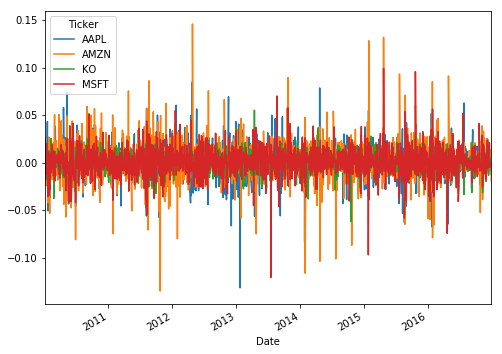

In [6]:
daily_returns=calc_daily_returns(closes)
daily_returns.plot(figsize=(8,6));

In [7]:
mean_daily_returns = pd.DataFrame(daily_returns.mean(),columns=['Mean'],index=daily_returns.columns)
mean_daily_returns

,Mean
Ticker,
AAPL,8.094e-04
AMZN,9.783e-04
KO,3.316e-04
MSFT,5.011e-04


In [8]:
cov_matrix = daily_returns.cov()
cov_matrix

Ticker,AAPL,AMZN,KO,MSFT
Ticker,,,,
AAPL,2.730e-04,1.104e-04,4.605e-05,9.506e-05
AMZN,1.104e-04,4.131e-04,5.615e-05,1.200e-04
KO,4.605e-05,5.615e-05,9.051e-05,5.659e-05
MSFT,9.506e-05,1.200e-04,5.659e-05,2.126e-04


In [9]:
#robust_cov_matrix= pd.DataFrame(skcov.EmpiricalCovariance().fit(daily_returns).covariance_,columns=daily_returns.columns,index=daily_returns.columns)
#robust_cov_matrix= pd.DataFrame(skcov.EllipticEnvelope().fit(daily_returns).covariance_,columns=daily_returns.columns,index=daily_returns.columns)
#robust_cov_matrix= pd.DataFrame(skcov.MinCovDet().fit(daily_returns).covariance_,columns=daily_returns.columns,index=daily_returns.columns)
robust_cov_matrix= pd.DataFrame(skcov.ShrunkCovariance().fit(daily_returns).covariance_,columns=daily_returns.columns,index=daily_returns.columns)
robust_cov_matrix

Ticker,AAPL,AMZN,KO,MSFT
Ticker,,,,
AAPL,2.703e-04,9.927e-05,4.142e-05,8.551e-05
AMZN,9.927e-05,3.963e-04,5.051e-05,1.080e-04
KO,4.142e-05,5.051e-05,1.061e-04,5.090e-05
MSFT,8.551e-05,1.080e-04,5.090e-05,2.160e-04


# 4. Optimización de portafolios

In [10]:
num_portfolios = 25000
r=0.0001
results = np.zeros((3+len(assets),num_portfolios))
for i in range(num_portfolios):
    #Pesos
    weights = np.array(np.random.random(4))
    weights /= np.sum(weights)
 
    #Rendimiento y volatilidad
    portfolio_return = mean_daily_returns.T.dot(weights) * 252
    portfolio_std_dev = np.sqrt(np.dot(weights.T,np.dot(robust_cov_matrix, weights))) * np.sqrt(252)
 
    #Resultados
    results[0,i] = portfolio_return
    results[1,i] = portfolio_std_dev
    #Sharpe
    results[2,i] = (results[0,i]-r) / results[1,i]
    #Iteraciones
    for j in range(len(weights)):
        results[j+3,i] = weights[j]

In [11]:
results_frame = pd.DataFrame(results.T,columns=(['Rendimiento','SD','Sharpe']+list(daily_returns.columns)))

In [12]:
#Sharpe Ratio
max_sharpe_port = results_frame.iloc[results_frame['Sharpe'].idxmax()]
#Menor SD
min_vol_port = results_frame.iloc[results_frame['SD'].idxmin()]

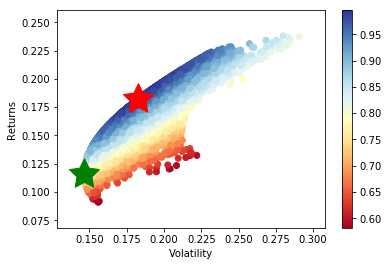

In [13]:
plt.scatter(results_frame.SD,results_frame.Rendimiento,c=results_frame.Sharpe,cmap='RdYlBu')
plt.xlabel('Volatility')
plt.ylabel('Returns')
plt.colorbar()
#Sharpe Ratio
plt.scatter(max_sharpe_port[1],max_sharpe_port[0],marker=(5,1,0),color='r',s=1000);
#Menor SD
plt.scatter(min_vol_port[1],min_vol_port[0],marker=(5,1,0),color='g',s=1000);

In [14]:
pd.DataFrame(max_sharpe_port)

,4361
Rendimiento,0.182
SD,0.183
Sharpe,0.995
AAPL,0.370
AMZN,0.317
KO,0.260
MSFT,0.052


In [15]:
pd.DataFrame(min_vol_port)

,16419
Rendimiento,0.116
SD,0.146
Sharpe,0.793
AAPL,0.157
AMZN,0.045
KO,0.649
MSFT,0.149
